# Data Download: SPY Historical Prices

downloading daily price data for **SPY** from Yahoo Finance, saving as CSV for the analysis pipeline.

In [1]:
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

## 1. Why SPY?

SPY tracks the S&P 500 index (500 largest US companies). most traded ETF in the world, super liquid, clean data with no gaps. yahoo handles all the adjustments. good for this project because its diversified so we dont get noise from single-stock events.

## 2. Configuration

In [2]:
TICKER     = "SPY"
START_DL   = "2005-12-01"   # padding before 2006 for clean month-end resampling
END_DL     = "2023-02-01"   # padding after 2023-01
SAVE_PATH  = f"data/{TICKER}-{START_DL}-to-{END_DL}.csv"

print(f"ticker     : {TICKER}")
print(f"download   : {START_DL} to {END_DL}")
print(f"save to    : {SAVE_PATH}")

ticker     : SPY
download   : 2005-12-01 to 2023-02-01
save to    : data/SPY-2005-12-01-to-2023-02-01.csv


downloading from 2005-12-01 to 2023-02-01, wider than the actual analysis period (2006 to 2023). the extra padding on both sides makes sure month-end resampling in EDA gives clean boundary months.

## 3. Download from Yahoo Finance

In [3]:
def download_spy(ticker, start, end):
    """download daily OHLCV from yfinance"""
    raw = yf.download(ticker, start=start, end=end)
    # flatten multi-level columns if present
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [col[0] for col in raw.columns]
    raw.index.name = "Date"
    return raw

raw = download_spy(TICKER, START_DL, END_DL)
print(f"rows     : {len(raw)}")
print(f"columns  : {list(raw.columns)}")
print(f"date range: {raw.index[0].date()} to {raw.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

rows     : 4320
columns  : ['Close', 'High', 'Low', 'Open', 'Volume']
date range: 2005-12-01 to 2023-01-31


got **4,320 daily rows** from 2005-12-01 to 2023-01-31. columns are `Close, High, Low, Open, Volume`. no separate `Adj Close` column because yfinance's newer API folds split adjustments directly into `Close`.

## 4. Snapshot

In [4]:
raw.head(10)

,Close,High,Low,Open,Volume
Date,,,,,
2005-12-01,86.758263,86.991095,86.272050,86.299438,65468200
2005-12-02,86.867844,87.025352,86.628162,86.813058,46699400
2005-12-05,86.682945,86.785667,86.409021,86.765119,59273400
2005-12-06,86.847290,87.477312,86.717175,87.004798,57935200
2005-12-07,86.340538,86.881537,86.066614,86.813052,66816500
2005-12-08,86.285751,86.847293,85.929654,86.436410,62608600
2005-12-09,86.511726,86.819888,86.162473,86.395310,50744500
2005-12-12,86.593910,86.874684,86.258356,86.771962,48389900
2005-12-13,87.182823,87.449898,86.484322,86.573345,88630900


In [5]:
raw.tail(5)

,Close,High,Low,Open,Volume
Date,,,,,
2023-01-25,383.794403,384.129935,377.285181,379.576361,84800300
2023-01-26,388.012451,388.175434,383.487635,386.459447,72287400
2023-01-27,388.904022,391.281478,386.756662,386.967565,68346200
2023-01-30,384.024506,388.376772,383.727327,386.143108,74202000
2023-01-31,389.670929,389.718850,384.197032,384.542161,86811800


## 5. Data Quality Checks

In [6]:
def check_quality(df):
    print(f"shape          : {df.shape}")
    print(f"missing values :")
    print(df.isna().sum().to_string())
    print(f"\nduplicates     : {df.index.duplicated().sum()}")
    print(f"sorted         : {df.index.is_monotonic_increasing}")
    print(f"\ndata types:")
    print(df.dtypes.to_string())

check_quality(raw)

shape          : (4320, 5)
missing values :
Close     0
High      0
Low       0
Open      0
Volume    0

duplicates     : 0
sorted         : True

data types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64


shape is (4320, 5). zero missing values across all columns, zero duplicate dates, chronologically sorted. data is clean, no imputation needed.

## 6. Quick Price Plot

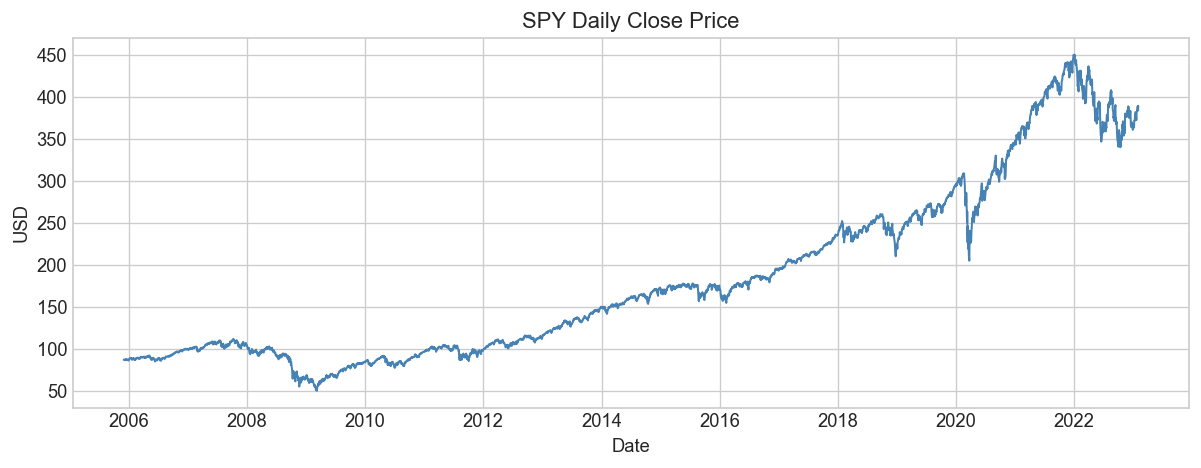

price column used: Close


In [7]:
def plot_close(df, ticker):
    col = "Adj Close" if "Adj Close" in df.columns else "Close"
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(df.index, df[col], color="steelblue", lw=1.2)
    ax.set(title=f"{ticker} Daily Close Price", xlabel="Date", ylabel="USD")
    plt.show()
    return col

used_col = plot_close(raw, TICKER)
print(f"price column used: {used_col}")

price goes from ~\$65 (Dec 2005) to ~\$390 (Jan 2023). the **2008 financial crisis** drop is massive, then **COVID crash** (Mar 2020) and the **2022 bear market**. this is raw daily data, EDA notebook will resample to monthly.

## 7. Quick Daily Return Stats

In [8]:
col = "Adj Close" if "Adj Close" in raw.columns else "Close"
daily_ret = raw[col].pct_change().dropna()

ann_ret = daily_ret.mean() * 252
ann_vol = daily_ret.std() * 252**0.5

print(f"daily returns : {len(daily_ret)} obs")
print(f"mean (daily)  : {daily_ret.mean():.6f}")
print(f"std  (daily)  : {daily_ret.std():.6f}")
print(f"min           : {daily_ret.min():.4f}")
print(f"max           : {daily_ret.max():.4f}")
print(f"annualised return (×252)    : {ann_ret*100:.2f}%")
print(f"annualised vol    (×√252)   : {ann_vol*100:.2f}%")

daily returns : 4319 obs
mean (daily)  : 0.000427
std  (daily)  : 0.012573
min           : -0.1094
max           : 0.1452
annualised return (×252)    : 10.76%
annualised vol    (×√252)   : 19.96%


annualised return $\approx 10.8\%$ ($\times 252$) and vol $\approx 20.0\%$ ($\times\sqrt{252}$). looks right for S&P 500 over this period which includes the 2008 crisis. daily min of $-10.9\%$ is the COVID crash, max of $+14.5\%$ is a crisis rebound day. data checks out.

## 8. Save to CSV

In [9]:
raw.to_csv(SAVE_PATH)
print(f"saved {len(raw)} rows to {SAVE_PATH}")
print(f"file size: {os.path.getsize(SAVE_PATH) / 1024:.1f} KB")

saved 4320 rows to data/SPY-2005-12-01-to-2023-02-01.csv
file size: 396.6 KB
